### HW 2

In [2]:
%load_ext autoreload
%autoreload 2
    
from wav2vec2decoder import Wav2Vec2Decoder

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### Part 1 — CTC Decoding <br>


**Task 1.** Implement `greedy_decode`

Evaluate on `data/librispeech_test_other/` and report CER & WER. Reference values: **WER ≈ 10.4%, CER ≈ 3.5%**

In [2]:
decoder = Wav2Vec2Decoder()

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


In [3]:
path_to_data = 'data/librispeech_test_other/'

In [4]:
import os
from os.path import join
import pandas as pd


manifest = pd.read_csv(join(path_to_data, 'manifest.csv'))
manifest.head(10)

,path,text
0,data/librispeech_test_other/sample_0.wav,i am from the cutter lying off the coast
1,data/librispeech_test_other/sample_1.wav,don't cry he said i was obliged to come
2,data/librispeech_test_other/sample_2.wav,and and you have not found out anything came i...
3,data/librispeech_test_other/sample_3.wav,i wish you would believe me that i am in as gr...
4,data/librispeech_test_other/sample_4.wav,that my father sir risdon graeme has smuggled ...
5,data/librispeech_test_other/sample_5.wav,he could not help it he hates the smugglers yo...
6,data/librispeech_test_other/sample_6.wav,pray pray say you will not archy was silent
7,data/librispeech_test_other/sample_7.wav,then as archy stood in the dark literally agha...
8,data/librispeech_test_other/sample_8.wav,he laughed but it was a curious kind of laugh ...
9,data/librispeech_test_other/sample_9.wav,it all comes of dressing up in this stupid way...


In [5]:
path_to_text = {k: v for k, v in zip(manifest['path'], manifest['text'])}

In [6]:
import jiwer
from tqdm import tqdm
import torchaudio

In [8]:
refs = []
hyps = []

wer_values = []
cer_values = []

for path, text in tqdm(path_to_text.items()):
    audio_input, sr = torchaudio.load(path)
    assert sr == 16000, f"Expected 16kHz, got {sr} for {path}"

    hyp = decoder.decode(audio_input, method='greedy')

    ref = " ".join(text.lower().strip().split())
    hyp = " ".join(hyp.lower().strip().split())

    wer = jiwer.wer(ref, hyp)
    cer = jiwer.cer(ref, hyp)
    wer_values.append(wer)
    cer_values.append(cer)

    print("=" * 50)
    print("file:", path)
    print("REF:", ref)
    print("HYP:", hyp)

    refs.append(ref)
    hyps.append(hyp)

wer = jiwer.wer(refs, hyps)
cer = jiwer.cer(refs, hyps)

print('\n')
print(f"Total samples: {len(hyps)}")
print(f"Greedy WER: {wer:.2%}")
print(f"Greedy CER: {cer:.2%}")

  0%|▍                                                                                              | 1/200 [00:00<01:19,  2.49it/s]

file: data/librispeech_test_other/sample_0.wav
REF: i am from the cutter lying off the coast
HYP: i am from the car lying off the coast


  1%|▉                                                                                              | 2/200 [00:00<01:25,  2.32it/s]

file: data/librispeech_test_other/sample_1.wav
REF: don't cry he said i was obliged to come
HYP: don't cry he said i was obliged to come


  2%|█▍                                                                                             | 3/200 [00:01<02:09,  1.52it/s]

...

file: data/librispeech_test_other/sample_197.wav
REF: to some with a smart souse on the epigaster he would make their midriff swag then redoubling the blow gave them such a homepush on the navel that he made their puddings to gush out
HYP: to some wou they smart sos on the ebogaster he would make their middrift wag then redoubling the blow gave them such a home push on the naval that he made their puddings to gush out


100%|████████████████████████████████████████████████████████████████████████████████████████████▌| 199/200 [03:35<00:01,  1.80s/it]

file: data/librispeech_test_other/sample_198.wav
REF: believe that it was the most horrible spectacle that ever one saw
HYP: believe that it was the most horrible spectacle that ever one saw


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [03:37<00:00,  1.09s/it]

file: data/librispeech_test_other/sample_199.wav
REF: o the holy lady nytouch said one the good sanctess o our lady of succours said another help help
HYP: oh the holy lady nightigh said one the good sanctis oh our lady of sacures said another help help


Total samples: 200
Greedy WER: 11.22%
Greedy CER: 3.81%


Total samples: 200
Greedy WER: 11.22%
Greedy CER: 3.81%

**Task 2.** Implement `beam_search_decode`.

Evaluate on `data/librispeech_test_other/` and report CER & WER. Reference values: **WER ≈ 9.9%, CER ≈ 3.4%**

Vary `beam_width` (e.g. 1, 3, 10, 50) and observe quality vs. compute trade-off, add corresponding graph/table to report.

In [7]:
decoder = Wav2Vec2Decoder(lm_model_path=None, beam_width=3)

refs = []
hyps = []

for path, text in tqdm(path_to_text.items()):
    audio_input, sr = torchaudio.load(path)
    assert sr == 16000

    if audio_input.shape[0] > 1:
        audio_input = audio_input.mean(dim=0, keepdim=True)

    hyp = decoder.decode(audio_input, method="beam")

    ref = " ".join(text.lower().strip().split())
    hyp = " ".join(hyp.lower().strip().split())

    refs.append(ref)
    hyps.append(hyp)

print("WER:", jiwer.wer(refs, hyps))
print("CER:", jiwer.cer(refs, hyps))

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [04:17<00:00,  1.29s/it]

WER: 0.11146418968467367
CER: 0.03783731408361998


In [18]:
import time

beam_widths = [1, 3, 10, 50]

wers = []
cers = []
times = []

for bw in beam_widths:
    decoder = Wav2Vec2Decoder(lm_model_path=None, beam_width=bw)

    refs = []
    hyps = []

    start_time = time.time()

    for path, text in tqdm(path_to_text.items(), desc=f"beam_width={bw}"):
        audio_input, sr = torchaudio.load(path)
        assert sr == 16000

        if audio_input.shape[0] > 1:
            audio_input = audio_input.mean(dim=0, keepdim=True)

        hyp = decoder.decode(audio_input, method="beam")

        ref = " ".join(text.lower().strip().split())
        hyp = " ".join(hyp.lower().strip().split())

        refs.append(ref)
        hyps.append(hyp)

    elapsed = time.time() - start_time

    wer = jiwer.wer(refs, hyps)
    cer = jiwer.cer(refs, hyps)

    wers.append(wer)
    cers.append(cer)
    times.append(elapsed)

    print(f"beam_width={bw}: WER={wer:.2%}, CER={cer:.2%}, time={elapsed:.2f}s")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
beam_width=1: 100%|███████████████████████████████████████████████████████████████████████████████| 200/200 [02:45<00:00,  1.21it/s]


beam_width=1: WER=11.24%, CER=3.80%, time=165.67s


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
beam_width=3: 100%|███████████████████████████████████████████████████████████████████████████████| 200/200 [02:52<00:00,  1.16it/s]


...

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
beam_width=10: 100%|██████████████████████████████████████████████████████████████████████████████| 200/200 [03:38<00:00,  1.09s/it]


beam_width=10: WER=11.07%, CER=3.77%, time=218.36s


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
beam_width=50: 100%|██████████████████████████████████████████████████████████████████████████████| 200/200 [09:34<00:00,  2.87s/it]

beam_width=50: WER=11.10%, CER=3.77%, time=574.70s


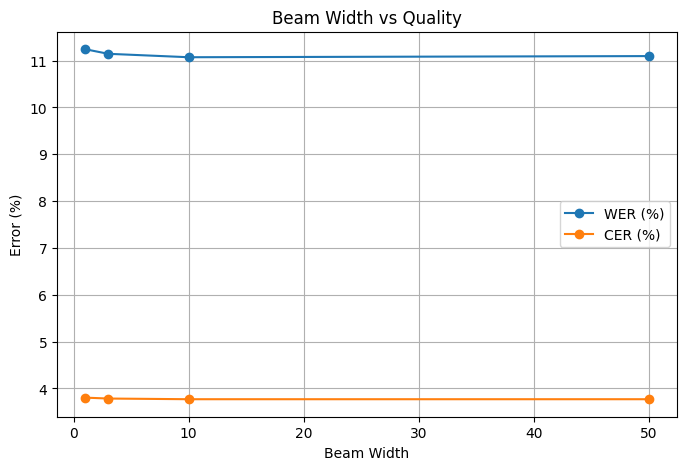

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(beam_widths, [w * 100 for w in wers], marker='o', label='WER (%)')
plt.plot(beam_widths, [c * 100 for c in cers], marker='o', label='CER (%)')

plt.xlabel("Beam Width")
plt.ylabel("Error (%)")
plt.title("Beam Width vs Quality")

plt.legend()
plt.grid(True)
plt.show()

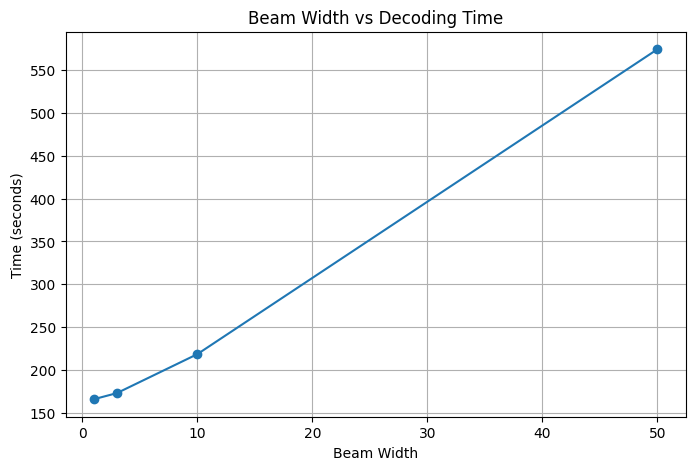

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(beam_widths, times, marker='o')

plt.xlabel("Beam Width")
plt.ylabel("Time (seconds)")
plt.title("Beam Width vs Decoding Time")

plt.grid(True)
plt.show()

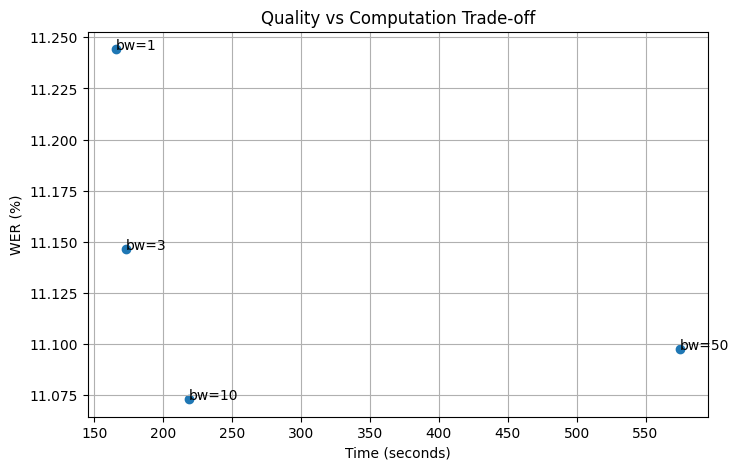

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(times, [w * 100 for w in wers])

for i, bw in enumerate(beam_widths):
    plt.annotate(f"bw={bw}", (times[i], wers[i] * 100))

plt.xlabel("Time (seconds)")
plt.ylabel("WER (%)")
plt.title("Quality vs Computation Trade-off")

plt.grid(True)
plt.show()

**Task 3.** Implement **temperature scaling** for acoustic model outputs.

The `temperature` parameter is already wired into `Wav2Vec2Decoder.__init__`. Inside `decode()`:
```python
logits = logits / self.temperature   # already implemented — do NOT modify
log_probs = torch.log_softmax(logits, dim=-1)
```

Make sure your decoders use `log_probs` (not raw logits) computed this way.

Run a sweep over `T ∈ {0.5, 0.8, 1.0, 1.2, 1.5, 2.0}` on `data/librispeech_test_other/` using **greedy decoding only** and observe how WER changes.

Explain in your report what effect does temperature have on greedy decoding?

> The interaction between temperature and LM fusion is studied in Task 7 on out-of-domain data, where the effect is much more pronounced.

In [16]:
temperatures = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]

for T in temperatures:
    decoder = Wav2Vec2Decoder(
        lm_model_path=None,
        temperature=T
    )

    refs = []
    hyps = []

    for path, text in tqdm(path_to_text.items(), desc=f"T={T}"):
        audio_input, sr = torchaudio.load(path)
        assert sr == 16000

        hyp = decoder.decode(audio_input, method="greedy")
        ref = " ".join(text.lower().strip().split())
        hyp = " ".join(hyp.lower().strip().split())

        refs.append(ref)
        hyps.append(hyp)

    wer = jiwer.wer(refs, hyps)
    cer = jiwer.cer(refs, hyps)

    print(f"Temperature={T}: WER={wer:.2%}, CER={cer:.2%}")

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
T=0.5: 100%|██████████████████████████████████████████████████████████████████████████████████████| 200/200 [03:32<00:00,  1.06s/it]


Temperature=0.5: WER=11.22%, CER=3.81%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
T=0.8: 100%|██████████████████████████████████████████████████████████████████████████████████████| 200/200 [03:17<00:00,  1.01it/s]


...

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
T=1.5: 100%|██████████████████████████████████████████████████████████████████████████████████████| 200/200 [03:20<00:00,  1.00s/it]


Temperature=1.5: WER=11.22%, CER=3.81%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
T=2.0: 100%|██████████████████████████████████████████████████████████████████████████████████████| 200/200 [03:19<00:00,  1.00it/s]

Temperature=2.0: WER=11.22%, CER=3.81%


##### Part 2 — Language Model Integration

**Task 4.** Implement `beam_search_with_lm` — shallow fusion of the provided **3-gram LM**.

Evaluate on `data/librispeech_test_other/`. Reference values at best params: **WER ≈ 9.7%, CER ≈ 3.4%**

Run a sweep over `alpha ∈ {0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0}` and `beta ∈ {0.0, 0.5, 1.0, 1.5}`. Report results in a heatmap or table and identify the best configuration.

The extended alpha range is intentional: at very low alpha the LM has no influence, at very high alpha it dominates and degrades quality. Note: the acoustic model is already strong in-domain, so the optimal alpha could be very small.

In [112]:
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
betas = [0.0, 0.5, 1.0, 1.5]

results = []

for alpha in alphas:
    for beta in betas:
        decoder = Wav2Vec2Decoder(
            lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
            beam_width=10,
            alpha=alpha,
            beta=beta,
            temperature=1.0,
        )

        refs = []
        hyps = []

        for path, text in tqdm(path_to_text.items(), desc=f"a={alpha}, b={beta}"):
            audio_input, sr = torchaudio.load(path)
            assert sr == 16000

            hyp = decoder.decode(audio_input, method="beam_lm")

            ref = " ".join(text.lower().strip().split())
            hyp = " ".join(hyp.lower().strip().split())

            refs.append(ref)
            hyps.append(hyp)

        wer = jiwer.wer(refs, hyps)
        cer = jiwer.cer(refs, hyps)

        results.append({
            "alpha": alpha,
            "beta": beta,
            "wer": wer,
            "cer": cer,
        })

        print(f"alpha={alpha}, beta={beta} -> WER={wer:.2%}, CER={cer:.2%}")

df = pd.DataFrame(results)
print(df.sort_values("wer"))

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
a=0.01, b=0.0: 100%|██████████████████████████████████████████████████████████████████████████████| 200/200 [05:06<00:00,  1.

alpha=0.01, beta=0.0 -> WER=11.07%, CER=3.77%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
a=0.01, b=0.5: 100%|██████████████████████████████████████████████████████████████████████████████| 200/200 [05:10<00:00,  1.

...

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
a=5.0, b=1.0: 100%|███████████████████████████████████████████████████████████████████████████████| 200/200 [06:05<00:00,  1.

alpha=5.0, beta=1.0 -> WER=29.45%, CER=8.36%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
a=5.0, b=1.5: 100%|███████████████████████████████████████████████████████████████████████████████| 200/200 [05:08<00:00,  1.

alpha=5.0, beta=1.5 -> WER=26.47%, CER=7.52%
    alpha  beta       wer       cer
9    0.10   0.5  0.109998  0.037498
4    0.05   0.0  0.110242  0.037644
14   0.50   1.0  0.110242  0.037498
19   1.00   1.5  0.110242  0.037644
5    0.05   0.5  0.110486  0.037547
1    0.01   0.5  0.110486  0.037595
8    0.10   0.0  0.110731  0.037740
10   0.10   1.0  0.110731  0.037547
15   0.50   1.5  0.110731  0.037547
0    0.01   0.0  0.110731  0.037692
13   0.50   0.5  0.111220  0.037740
2    0.01   1.0  0.112198  0.037886
6    0.05   1.0  0.112442  0.037837
18   1.00   1.0  0.112686  0.037983
11   0.10   1.5  0.112931  0.037886
3    0.01   1.5  0.113175  0.037934
7    0.05   1.5  0.113175  0.037934
12   0.50   0.0  0.114153  0.038176
16   1.00   0.0  0.115864  0.038564
23   2.00   1.5  0.115864  0.038516
17   1.00   0.5  0.116109  0.038564
22   2.00   1.0  0.120997  0.039339
21   2.00   0.5  0.124664  0.039872
20   2.00   0.0  0.136886  0.041568
27   5.00   1.5  0.264727  0.075190
26   5.00   1.0  0.

In [116]:
df.sort_values("wer")

,alpha,beta,wer,cer
0,0.10,0.5,0.109998,0.037498
1,0.05,0.0,0.110242,0.037644
2,0.50,1.0,0.110242,0.037498
3,1.00,1.5,0.110242,0.037644
4,0.05,0.5,0.110486,0.037547
5,0.01,0.5,0.110486,0.037595
6,0.10,0.0,0.110731,0.037740
7,0.10,1.0,0.110731,0.037547
8,0.50,1.5,0.110731,0.037547
9,0.01,0.0,0.110731,0.037692


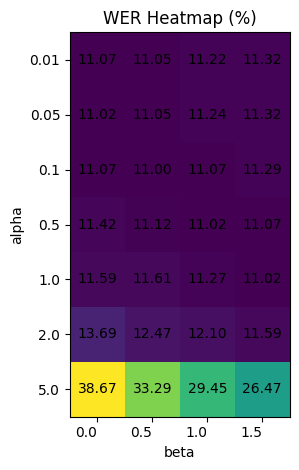

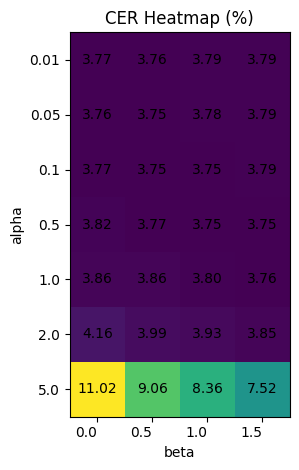

In [117]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

wer_table = df.pivot(index="alpha", columns="beta", values="wer")
cer_table = df.pivot(index="alpha", columns="beta", values="cer")


def plot_heatmap(table, title):
    data = table.values

    fig, ax = plt.subplots()
    c = ax.imshow(data)

    ax.set_xticks(np.arange(len(table.columns)))
    ax.set_yticks(np.arange(len(table.index)))

    ax.set_xticklabels(table.columns)
    ax.set_yticklabels(table.index)

    plt.setp(ax.get_xticklabels(), ha="right")

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i, j]*100:.2f}",
                    ha="center", va="center")

    ax.set_title(title)
    ax.set_xlabel("beta")
    ax.set_ylabel("alpha")

    plt.tight_layout()
    plt.show()


plot_heatmap(wer_table, "WER Heatmap (%)")
plot_heatmap(cer_table, "CER Heatmap (%)")

**Task 5.** Download the **4-gram LM** from [openslr.org/11](http://www.openslr.org/11/) and plug it into `beam_search_with_lm`.

Evaluate on `data/librispeech_test_other/` with the best `alpha`/`beta` from Task 4. Report results in a table alongside the 3-gram baseline.

In [121]:
decoder = Wav2Vec2Decoder(
            lm_model_path="lm/4-gram.arpa.gz",
            beam_width=10,
            alpha=0.1,
            beta=0.5,
            temperature=1.0,
)

refs = []
hyps = []
alpha = 0.1
beta = 0.5

for path, text in tqdm(path_to_text.items(), desc=f"a={alpha}, b={beta}"):
    audio_input, sr = torchaudio.load(path)
    assert sr == 16000

    hyp = decoder.decode(audio_input, method="beam_lm")

    ref = " ".join(text.lower().strip().split())
    hyp = " ".join(hyp.lower().strip().split())

    refs.append(ref)
    hyps.append(hyp)

wer = jiwer.wer(refs, hyps)
cer = jiwer.cer(refs, hyps)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/4-gram.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
a=0.1, b=0.5: 100%|███████████████████████████████████████████████████████████████████████████████| 200/200 [05:48<00:00,  1.74s/it]


In [122]:
wer, cer

(0.11048643363480812, 0.037546630492708684)


| LM | alpha | beta | WER (%) | CER (%) |
|---|---:|---:|---:|---:|
| 3-gram | 0.1 | 0.5 | 11.00 | 3.75 |
| 4-gram | 0.1 | 0.5 | 11.05 | 3.75 |

**Task 6.** Implement `lm_rescore` — second-pass LM rescoring of beam hypotheses.

Evaluate on `data/librispeech_test_other/`. Reference values at best params: **WER ≈ 9.6%, CER ≈ 3.3%**

Run a sweep over `alpha` and `beta` (same grid as Task 4: `alpha ∈ {0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0}`, `beta ∈ {0.0, 0.5, 1.0, 1.5}`). Report results in a table. Compare rescoring vs shallow fusion — which is more stable to large `alpha` values and why?



In [7]:
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
betas = [0.0, 0.5, 1.0, 1.5]

results = []

for alpha in alphas:
    for beta in betas:
        decoder = Wav2Vec2Decoder(
            lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
            beam_width=10,
            alpha=alpha,
            beta=beta,
            temperature=1.0,
        )

        refs = []
        hyps = []

        for path, text in tqdm(path_to_text.items(), desc=f"a={alpha}, b={beta}"):
            audio_input, sr = torchaudio.load(path)
            assert sr == 16000

            hyp = decoder.decode(audio_input, method="beam_lm_rescore")

            ref = " ".join(text.lower().strip().split())
            hyp = " ".join(hyp.lower().strip().split())

            refs.append(ref)
            hyps.append(hyp)

        wer = jiwer.wer(refs, hyps)
        cer = jiwer.cer(refs, hyps)

        results.append({
            "alpha": alpha,
            "beta": beta,
            "wer": wer,
            "cer": cer,
        })

        print(f"alpha={alpha}, beta={beta} -> WER={wer:.2%}, CER={cer:.2%}")

df = pd.DataFrame(results)
print(df.sort_values("wer"))

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
a=0.01, b=0.0: 100%|██████████████████████████████████████████████████████████████████████████████| 200/200 [05:48<00:00,  1.

alpha=0.01, beta=0.0 -> WER=11.07%, CER=3.77%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
a=0.01, b=0.5: 100%|██████████████████████████████████████████████████████████████████████████████| 200/200 [06:06<00:00,  1.

...

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
a=5.0, b=1.0: 100%|███████████████████████████████████████████████████████████████████████████████| 200/200 [04:04<00:00,  1.

alpha=5.0, beta=1.0 -> WER=12.81%, CER=3.99%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
a=5.0, b=1.5: 100%|███████████████████████████████████████████████████████████████████████████████| 200/200 [04:13<00:00,  1.

alpha=5.0, beta=1.5 -> WER=12.69%, CER=3.97%
    alpha  beta       wer       cer
3    0.01   1.5  0.109998  0.037401
7    0.05   1.5  0.109998  0.037450
11   0.10   1.5  0.109998  0.037450
9    0.10   0.5  0.109998  0.037547
15   0.50   1.5  0.109998  0.037498
5    0.05   0.5  0.110242  0.037547
1    0.01   0.5  0.110242  0.037547
14   0.50   1.0  0.110486  0.037644
13   0.50   0.5  0.110731  0.037740
8    0.10   0.0  0.110731  0.037740
0    0.01   0.0  0.110731  0.037692
4    0.05   0.0  0.110731  0.037692
19   1.00   1.5  0.110731  0.037692
6    0.05   1.0  0.110975  0.037595
10   0.10   1.0  0.110975  0.037595
2    0.01   1.0  0.110975  0.037595
18   1.00   1.0  0.112931  0.037934
12   0.50   0.0  0.113420  0.038031
17   1.00   0.5  0.114153  0.038128
16   1.00   0.0  0.115131  0.038322
23   2.00   1.5  0.115131  0.038322
21   2.00   0.5  0.117086  0.038612
22   2.00   1.0  0.117575  0.038612
20   2.00   0.0  0.120264  0.039000
27   5.00   1.5  0.126864  0.039678
25   5.00   0.5  0.

In [8]:
df.sort_values("wer")

,alpha,beta,wer,cer
3,0.01,1.5,0.109998,0.037401
7,0.05,1.5,0.109998,0.037450
11,0.10,1.5,0.109998,0.037450
9,0.10,0.5,0.109998,0.037547
15,0.50,1.5,0.109998,0.037498
5,0.05,0.5,0.110242,0.037547
1,0.01,0.5,0.110242,0.037547
14,0.50,1.0,0.110486,0.037644
13,0.50,0.5,0.110731,0.037740
8,0.10,0.0,0.110731,0.037740


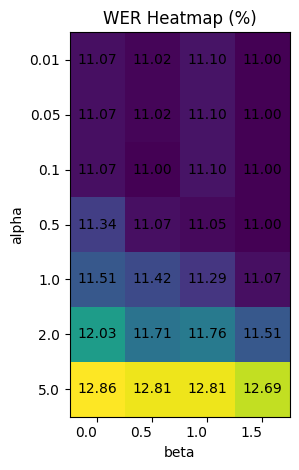

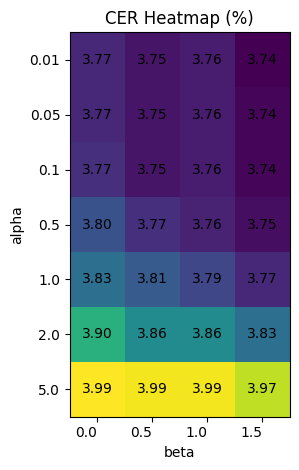

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

wer_table = df.pivot(index="alpha", columns="beta", values="wer")
cer_table = df.pivot(index="alpha", columns="beta", values="cer")


def plot_heatmap(table, title):
    data = table.values

    fig, ax = plt.subplots()
    c = ax.imshow(data)

    ax.set_xticks(np.arange(len(table.columns)))
    ax.set_yticks(np.arange(len(table.index)))

    ax.set_xticklabels(table.columns)
    ax.set_yticklabels(table.index)

    plt.setp(ax.get_xticklabels(), ha="right")

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i, j]*100:.2f}",
                    ha="center", va="center")

    ax.set_title(title)
    ax.set_xlabel("beta")
    ax.set_ylabel("alpha")

    plt.tight_layout()
    plt.show()


plot_heatmap(wer_table, "WER Heatmap (%)")
plot_heatmap(cer_table, "CER Heatmap (%)")

Pick **5–10 samples** from `data/librispeech_test_other/` where at least one LM method changes the hypothesis relative to plain beam search, and present them as a qualitative comparison:

```
REF:  he had taken the wrong road entirely
BEAM: he had taken the rong road entirely
SF:   he had taken the wrong road entirely   ✓ corrected
RS:   he had taken the wrong road entirely   ✓ corrected

REF:  the committee met on thursday
BEAM: the committee met on thursday
SF:   the comittee met on thurzday          ✗ introduced error
RS:   the committee met on thursday         ✓ unchanged
```

In your report, look for patterns and answer:
- What kinds of errors does the LM tend to fix? (e.g. real-word confusions, rare words, sentence endings)
- What kinds of errors does it fail to fix or make worse? (e.g. acoustically similar but domain-mismatched words)
- Are there cases where shallow fusion and rescoring disagree? What does that reveal about the two methods?

---


In [123]:
beam_decoder = Wav2Vec2Decoder(
            lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
            beam_width=10,
            temperature=1.0,
        )
sf_decoder = Wav2Vec2Decoder(
            lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
            beam_width=10,
            alpha=0.1,
            beta=0.5,
            temperature=1.0,
        )
rs_decoder = Wav2Vec2Decoder(
            lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
            beam_width=10,
            alpha=0.01,
            beta=1.5,
            temperature=1.0,
        )


rows = []

for path, text in tqdm(path_to_text.items()):
    audio_input, sr = torchaudio.load(path)
    assert sr == 16000

    beam = beam_decoder.decode(audio_input, method="beam")
    sf = sf_decoder.decode(audio_input, method="beam_lm")
    rs = rs_decoder.decode(audio_input, method="beam_lm_rescore")

    ref = " ".join(text.lower().strip().split())
    beam = " ".join(beam.lower().strip().split())
    sf = " ".join(sf.lower().strip().split())
    rs = " ".join(rs.lower().strip().split())

    rows.append({
        "path": path,
        "ref": ref,
        "beam": beam,
        "sf": sf,
        "rs": rs,
        "beam_wer": jiwer.wer(ref, beam),
        "sf_wer": jiwer.wer(ref, sf),
        "rs_wer": jiwer.wer(ref, rs),
    })

df = pd.DataFrame(rows)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [12:32<00:00,  3.

In [124]:
# 1. Где LM исправил ошибку beam
fixed = df[
    (df["beam_wer"] > df["sf_wer"]) | 
    (df["beam_wer"] > df["rs_wer"])
]

# 2. Где SF ухудшил, а RS норм
sf_broke = df[
    (df["sf_wer"] > df["beam_wer"]) &
    (df["rs_wer"] <= df["beam_wer"])
]

# 2. Где RS ухудшил, а SF норм

rs_broke = df[
    (df["rs_wer"] > df["beam_wer"]) &
    (df["sf_wer"] <= df["beam_wer"])
]

# 4. Где SF и RS расходятся
disagree = df[
    df["sf"] != df["rs"]
]

In [125]:
print(len(fixed), len(sf_broke), len(rs_broke), len(disagree))

9 0 7 15


In [126]:
# Собираем топ примеров
examples = pd.concat([
    fixed.sort_values("beam_wer", ascending=False).head(4),
    sf_broke.head(3),
    rs_broke.head(3),
    disagree.head(3),
]).drop_duplicates()

print(len(examples))

9


In [127]:
examples

,path,ref,beam,sf,rs,beam_wer,sf_wer,rs_wer
33,data/librispeech_test_other/sample_33.wav,and why did andy call mister gurr father,and why did andy call mister gurfather,and why did andy call mister gur father,and why did andy call mister gur father,0.250000,0.125000,0.125000
112,data/librispeech_test_other/sample_112.wav,gurr glanced round to see if the men were look...,gur glanced round to see if the men were looki...,gur glanced round to see if the men were looki...,gur glanced round to see if the men were looki...,0.235294,0.235294,0.176471
105,data/librispeech_test_other/sample_105.wav,pipe away the men to that boat there he said a...,pip away the men to that boat there he said an...,pip away the men to that boat there he said an...,pip away the men to that boat there he said an...,0.187500,0.187500,0.062500
67,data/librispeech_test_other/sample_67.wav,it was your turn yesterday it's mine to day wh...,it was your turn yesterday it's mine today wha...,it was your turn yesterday it's mine today wha...,it was your turn yesterday it's mine to day wh...,0.166667,0.166667,0.000000
88,data/librispeech_test_other/sample_88.wav,no wait another half hour,no where another anda half hour,no where another anda half hour,no where another an a half hour,0.400000,0.400000,0.600000
139,data/librispeech_test_other/sample_139.wav,do as they do and belike thou shalt gain what ...,do as thy do and belike thou shalt gain what m...,do as thy do and belike thou shalt gain what m...,do as thy do and be like thou shalt gain what ...,0.157895,0.157895,0.263158
163,data/librispeech_test_other/sample_163.wav,o my brother answered he we are husbandmen and...,o my brother answered he we are husbandman ant...,o my brother answered he we are husbandman ant...,o my brother answered he we are husbandman ant...,0.108696,0.108696,0.130435
14,data/librispeech_test_other/sample_14.wav,the kick he had received was a foretaste of wh...,the kickhe had received was a foretaste of wha...,the kickhe had received was a foretaste of wha...,the kick he had received was a fore taste of w...,0.050000,0.050000,0.050000
28,data/librispeech_test_other/sample_28.wav,stop here till sir risdon comes down and tell ...,stop here till sir rysdon comes down and tell ...,stop here till sir rysdon comes down and tell ...,stop here till sir rysdon comes down and tell ...,0.083333,0.083333,0.041667


In [128]:
def print_examples(df):
    for _, row in df.iterrows():
        print("REF: ", row["ref"])
        print("BEAM:", row["beam"])
        print("SF:  ", row["sf"])
        print("RS:  ", row["rs"])

        if row["sf_wer"] < row["beam_wer"]:
            print("      SF ✓ improved")
        elif row["sf_wer"] > row["beam_wer"]:
            print("      SF ✗ worse")

        if row["rs_wer"] < row["beam_wer"]:
            print("      RS ✓ improved")
        elif row["rs_wer"] > row["beam_wer"]:
            print("      RS ✗ worse")

        print("-" * 60)

print_examples(examples.head(10))

REF:  and why did andy call mister gurr father
BEAM: and why did andy call mister gurfather
SF:   and why did andy call mister gur father
RS:   and why did andy call mister gur father
      SF ✓ improved
      RS ✓ improved
------------------------------------------------------------
REF:  gurr glanced round to see if the men were looking and then said rather huskily but kindly
BEAM: gur glanced round to see if the men were looking and then said lether huskily bekindly
SF:   gur glanced round to see if the men were looking and then said lether huskily bekindly
RS:   gur glanced round to see if the men were looking and then said lether huskily be kindly
      RS ✓ improved
------------------------------------------------------------
REF:  pipe away the men to that boat there he said and as the crew sprang in
BEAM: pip away the men to that boat there he said and as the crewsprang in
SF:   pip away the men to that boat there he said and as the crewsprang in
RS:   pip away the men to that 

**Task 7.** Evaluate your best shallow-fusion and rescoring configurations (from Tasks 4–6) on `data/earnings22_test/`.

Present a comparison table across all 4 decoding methods on both test sets:

| Method | LibriSpeech WER | LibriSpeech CER | Earnings22 WER | Earnings22 CER |
|---|---|---|---|---|
| Greedy | - | - | - | - |
| Beam search | - | - | — | — |
| Beam + 3-gram (shallow fusion) | - | - | — | — |
| Beam + 3-gram (rescoring) | - | - | — | — |

*(Fill in all values from your experiments.)*

Discuss the gap between in-domain and out-of-domain performance. Why does the LibriSpeech LM provide almost no benefit on financial speech?

In [7]:
def evaluate(dataset, decoder, method):
    refs, hyps = [], []

    for path, text in tqdm(dataset.items(), desc=method):
        audio_input, sr = torchaudio.load(path)
        assert sr == 16000

        hyp = decoder.decode(audio_input, method=method)

        ref = " ".join(text.lower().strip().split())
        hyp = " ".join(hyp.lower().strip().split())

        refs.append(ref)
        hyps.append(hyp)

    wer = jiwer.wer(refs, hyps)
    cer = jiwer.cer(refs, hyps)

    return wer, cer

In [8]:
librispeech = path_to_text

In [9]:
path_to_data = 'data/earnings22_test/'

In [10]:
manifest = pd.read_csv(join(path_to_data, 'manifest.csv'))
manifest.head(10)

,path,text
0,data/earnings22_test/sample_000000.wav,but happy with what we've been seeing here
1,data/earnings22_test/sample_000001.wav,i just just curious to get your sense on on ki...
2,data/earnings22_test/sample_000002.wav,you also saw that we have a new leader lee she...
3,data/earnings22_test/sample_000003.wav,uh and for the full year
4,data/earnings22_test/sample_000004.wav,uh morning uh oliver and stefan
5,data/earnings22_test/sample_000005.wav,as you would expect now obviously some of the ...
6,data/earnings22_test/sample_000006.wav,yeah maybe uh a thought would be uh competitio...
7,data/earnings22_test/sample_000007.wav,firstly part of the growth stems from higher v...
8,data/earnings22_test/sample_000008.wav,like just to really understand what are the w ...
9,data/earnings22_test/sample_000009.wav,but use these joint use case use cases and suc...


In [11]:
manifest['text'][20]

'welcome to the conference call of teamviewer ag'

In [12]:
path_to_text = {k: v for k, v in zip(manifest['path'], manifest['text'])}

In [13]:
earnings = path_to_text

In [15]:
greedy_decoder = Wav2Vec2Decoder(
    lm_model_path=None,
    temperature=1.0
)

beam_decoder = Wav2Vec2Decoder(
    lm_model_path=None,
    beam_width=10
)

sf_decoder = Wav2Vec2Decoder(
    lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
    beam_width=10,
    alpha=0.1,
    beta=0.5
)

rs_decoder = Wav2Vec2Decoder(
    lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
    beam_width=10,
    alpha=0.01,
    beta=1.5
)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


In [16]:
results = []

methods = [
    ("Greedy", greedy_decoder, "greedy"),
    ("Beam search", beam_decoder, "beam"),
    ("Beam + 3-gram (SF)", sf_decoder, "beam_lm"),
    ("Beam + 3-gram (RS)", rs_decoder, "beam_lm_rescore"),
]

for name, decoder, method in methods:
    print(f"\n{name} — LibriSpeech")
    wer_ls, cer_ls = evaluate(librispeech, decoder, method)

    print(f"{name} — Earnings22")
    wer_e, cer_e = evaluate(earnings, decoder, method)

    results.append({
        "Method": name,
        "LibriSpeech WER": wer_ls,
        "LibriSpeech CER": cer_ls,
        "Earnings22 WER": wer_e,
        "Earnings22 CER": cer_e,
    })

df = pd.DataFrame(results)
print(df)


Greedy — LibriSpeech


greedy: 100%|█████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:28<00:00,  1.35it/s]


Greedy — Earnings22


greedy: 100%|█████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:02<00:00,  1.63it/s]



Beam search — LibriSpeech


...


Beam + 3-gram (RS) — LibriSpeech


beam_lm_rescore: 100%|████████████████████████████████████████████████████████████████████████████| 200/200 [03:36<00:00,  1.08s/it]


Beam + 3-gram (RS) — Earnings22


beam_lm_rescore: 100%|████████████████████████████████████████████████████████████████████████████| 200/200 [03:18<00:00,  1.01it/s]

               Method  LibriSpeech WER  LibriSpeech CER  Earnings22 WER  \
0              Greedy         0.112198         0.038128        0.549699   
1         Beam search         0.110731         0.037692        0.549398   
2  Beam + 3-gram (SF)         0.109998         0.037498        0.553313   
3  Beam + 3-gram (RS)         0.109998         0.037401        0.553313   

   Earnings22 CER  
0        0.255623  
1        0.253622  
2        0.254001  
3        0.253622  


In [17]:
df.round(4)

,Method,LibriSpeech WER,LibriSpeech CER,Earnings22 WER,Earnings22 CER
0,Greedy,0.1122,0.0381,0.5497,0.2556
1,Beam search,0.1107,0.0377,0.5494,0.2536
2,Beam + 3-gram (SF),0.1100,0.0375,0.5533,0.2540
3,Beam + 3-gram (RS),0.1100,0.0374,0.5533,0.2536


**Task 7b.** Run a temperature sweep on `data/earnings22_test/` using your best shallow-fusion configuration from Task 4.

Sweep `T ∈ {0.5, 1.0, 1.5, 2.0}` and **plot WER vs T** for:
- Greedy decoding (reference: still flat — confirm this)
- Beam search with LM shallow fusion

Compare the resulting plot with the flat greedy curve from Task 3 (LibriSpeech). In your report, answer:
- Does higher temperature help or hurt LM fusion on out-of-domain speech, and why?
- On LibriSpeech the acoustic model is well-calibrated, so T > 1 degrades it. Is the same true for Earnings22? *(Hint: the acoustic model was never trained on financial speech — its confidence may be unreliable even at T = 1.)*

In [18]:
temps = [0.5, 1.0, 1.5, 2.0]

results = []

for T in temps:
    greedy_decoder = Wav2Vec2Decoder(
        lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
        beam_width=10,
        alpha=0.1,   # best SF params from Task 4
        beta=0.5,
        temperature=T,
    )

    sf_decoder = Wav2Vec2Decoder(
        lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
        beam_width=10,
        alpha=0.1,   # best SF params from Task 4
        beta=0.5,
        temperature=T,
    )

    refs = []
    greedy_hyps = []
    sf_hyps = []

    for path, text in tqdm(earnings.items(), desc=f"T={T}"):
        audio_input, sr = torchaudio.load(path)
        assert sr == 16000

        ref = " ".join(text.lower().strip().split())
        greedy_hyp = " ".join(greedy_decoder.decode(audio_input, method="greedy").lower().strip().split())
        sf_hyp = " ".join(sf_decoder.decode(audio_input, method="beam_lm").lower().strip().split())

        refs.append(ref)
        greedy_hyps.append(greedy_hyp)
        sf_hyps.append(sf_hyp)

    greedy_wer = jiwer.wer(refs, greedy_hyps)
    sf_wer = jiwer.wer(refs, sf_hyps)

    results.append({
        "temperature": T,
        "greedy_wer": greedy_wer,
        "sf_wer": sf_wer,
    })

    print(f"T={T}: greedy WER={greedy_wer:.2%}, SF WER={sf_wer:.2%}")

df_temp = pd.DataFrame(results)
print(df_temp)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
T=0.5: 100%|██████████████████████████████████████████████████████████████████████████████████████| 200/200 [06:09<00:00,  1.

T=0.5: greedy WER=54.97%, SF WER=55.18%


...

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
T=2.0: 100%|██████████████████████████████████████████████████████████████████████████████████████| 200/200 [06:09<00:00,  1.

T=2.0: greedy WER=54.97%, SF WER=57.65%
   temperature  greedy_wer    sf_wer
0          0.5    0.549699  0.551807
1          1.0    0.549699  0.553313
2          1.5    0.549699  0.562048
3          2.0    0.549699  0.576506


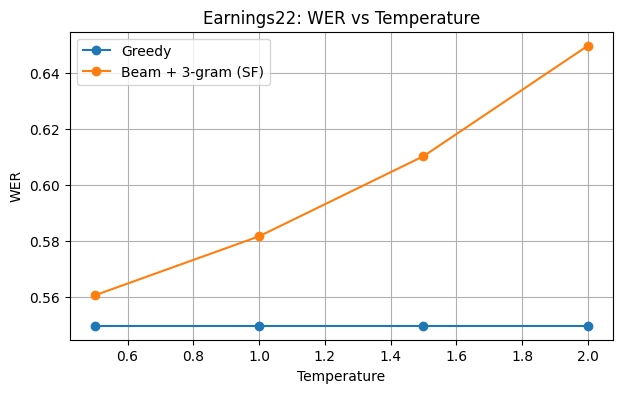

In [27]:
plt.figure(figsize=(7, 4))
plt.plot(df_temp["temperature"], df_temp["greedy_wer"], marker="o", label="Greedy")
plt.plot(df_temp["temperature"], df_temp["sf_wer"], marker="o", label="Beam + 3-gram (SF)")
plt.xlabel("Temperature")
plt.ylabel("WER")
plt.title("Earnings22: WER vs Temperature")
plt.legend()
plt.grid(True)
plt.show()

**Task 8.** Train a **financial-domain KenLM** model using `data/earnings22_train/corpus.txt` as your base training corpus (~5000 lines of real earnings-call speech).

You are free to extend the corpus with any additional financial text you can find (e.g. earnings call transcripts, financial news, SEC filings). More and more diverse data will produce a better LM and more interesting results in Task 9.

First, build the KenLM command-line tools (needed once — see the [KenLM docs](https://github.com/kpu/kenlm) for details):

```bash
# Linux
sudo apt-get install cmake libboost-all-dev
git clone --depth=1 https://github.com/kpu/kenlm /tmp/kenlm_build
mkdir /tmp/kenlm_build/build && cd /tmp/kenlm_build/build
cmake .. && make -j4 lmplz build_binary

# macOS
brew install cmake boost
git clone --depth=1 https://github.com/kpu/kenlm /tmp/kenlm_build
mkdir /tmp/kenlm_build/build && cd /tmp/kenlm_build/build
cmake .. && make -j4 lmplz build_binary
```

Then train a 3-gram model:

```bash
/tmp/kenlm_build/build/bin/lmplz -o 3 --discount_fallback \
    < data/earnings22_train/corpus.txt > /tmp/financial-3gram.arpa
gzip -c /tmp/financial-3gram.arpa > lm/financial-3gram.arpa.gz
```

The resulting `lm/financial-3gram.arpa.gz` can be loaded by `Wav2Vec2Decoder` via the `lm_model_path` argument.


In [80]:
import kenlm

lm = kenlm.Model("lm/financial-3gram.arpa.gz")

print(lm.score("welcome to the conference call", bos=True, eos=True))
print(lm.score("a second fish made its appearance", bos=True, eos=True))

-8.09764289855957
-23.932903289794922


Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/financial-3gram.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


In [29]:
decoder = Wav2Vec2Decoder(
    lm_model_path="lm/financial-3gram.arpa.gz",
    beam_width=10,
    alpha=0.01,
    beta=1.5,
)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/financial-3gram.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


**Task 9.** Apply your two best decoding methods using **both available LMs** (LibriSpeech 3-gram and your financial-domain LM) on both test sets.

Report all results in a table and add a bar chart comparing WER/CER per domain per LM. In your report, answer:
- Which LM works best in-domain? Out-of-domain?
- Does domain-matched LM help more than a larger general LM?

In [33]:
methods = ["beam_lm", "beam_lm_rescore"]

lms = {
    "librispeech_lm": "lm/3-gram.pruned.1e-7.arpa.gz",
    "financial_lm": "lm/financial-3gram.arpa.gz",
}

datasets = {
    "librispeech": librispeech,
    "earnings22": earnings,
}

method_params = {
    "beam_lm": {"alpha": 0.1, "beta": 0.5},
    "beam_lm_rescore": {"alpha": 0.01, "beta": 1.5},
}

results = []

for lm_name, lm_path in lms.items():
    for dataset_name, path_to_text in datasets.items():
        for method in methods:

            alpha = method_params[method]["alpha"]
            beta = method_params[method]["beta"]

            print(f"\nLM={lm_name}, dataset={dataset_name}, method={method}, alpha={alpha}, beta={beta}")

            decoder = Wav2Vec2Decoder(
                lm_model_path=lm_path,
                beam_width=10,
                alpha=alpha,
                beta=beta,
                temperature=1.0,
            )

            refs, hyps = [], []

            for path, text in tqdm(path_to_text.items()):
                audio_input, sr = torchaudio.load(path)
                assert sr == 16000

                hyp = decoder.decode(audio_input, method=method)

                ref = " ".join(text.lower().strip().split())
                hyp = " ".join(hyp.lower().strip().split())

                refs.append(ref)
                hyps.append(hyp)

            wer = jiwer.wer(refs, hyps)
            cer = jiwer.cer(refs, hyps)

            results.append({
                "LM": lm_name,
                "Dataset": dataset_name,
                "Method": method,
                "alpha": alpha,
                "beta": beta,
                "WER": wer,
                "CER": cer,
            })

            print(f"WER={wer:.2%}, CER={cer:.2%}")


LM=librispeech_lm, dataset=librispeech, method=beam_lm, alpha=0.1, beta=0.5


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/3-gram.pruned.1e-7.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [05:21<00:00,  1.

WER=11.00%, CER=3.75%

LM=librispeech_lm, dataset=librispeech, method=beam_lm_rescore, alpha=0.01, beta=1.5


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

...

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/financial-3gram.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [04:13<00:00,  1.27s

WER=52.41%, CER=24.99%

LM=financial_lm, dataset=earnings22, method=beam_lm_rescore, alpha=0.01, beta=1.5


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading the LM will be faster if you build a binary file.
Reading /home/ilya_treyvish/projects/ITMO_speech_recognition_and_generation_Assignments/HW2/lm/financial-3gram.arpa.gz
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [03:13<00:00,  1.03i

WER=55.18%, CER=25.34%


In [20]:
results

[{'LM': 'librispeech_lm',
  'Dataset': 'librispeech',
  'Method': 'beam_lm',
  'alpha': 0.1,
  'beta': 0.5,
  'WER': 0.10999755560987534,
  'CER': 0.037498183227556804},
 {'LM': 'librispeech_lm',
  'Dataset': 'librispeech',
  'Method': 'beam_lm_rescore',
  'alpha': 0.01,
  'beta': 1.5,
  'WER': 0.10999755560987534,
  'CER': 0.03740128869725304},
 {'LM': 'librispeech_lm',
  'Dataset': 'earnings22',
  'Method': 'beam_lm',
  'alpha': 0.1,
  'beta': 0.5,
  'WER': 0.5533132530120481,
  'CER': 0.2540008650519031},
 {'LM': 'librispeech_lm',
  'Dataset': 'earnings22',
  'Method': 'beam_lm_rescore',
  'alpha': 0.01,
  'beta': 1.5,
  'WER': 0.5533132530120481,
  'CER': 0.25362240484429066},
 {'LM': 'financial_lm',
  'Dataset': 'librispeech',
  'Method': 'beam_lm',
  'alpha': 0.1,
  'beta': 0.5,
  'WER': 0.10975311659740894,
  'CER': 0.03764352502301245},
 {'LM': 'financial_lm',
  'Dataset': 'librispeech',
  'Method': 'beam_lm_rescore',
  'alpha': 0.01,
  'beta': 1.5,
  'WER': 0.10999755560987534

In [23]:
df = pd.DataFrame(results)

# round for readability
df["WER"] = df["WER"].round(4)
df["CER"] = df["CER"].round(5)

# sort nicely
df = df.sort_values(["Dataset", "LM", "Method"])

table = df.pivot_table(
    index=["Dataset", "LM"],
    columns="Method",
    values=["WER", "CER"]
)

table

CER                     WER                
Method                      beam_lm beam_lm_rescore beam_lm beam_lm_rescore
Dataset     LM                                                             
earnings22  financial_lm    0.24995         0.25341  0.5241          0.5518
            librispeech_lm  0.25400         0.25362  0.5533          0.5533
librispeech financial_lm    0.03764         0.03745  0.1098          0.1100
            librispeech_lm  0.03750         0.03740  0.1100          0.1100

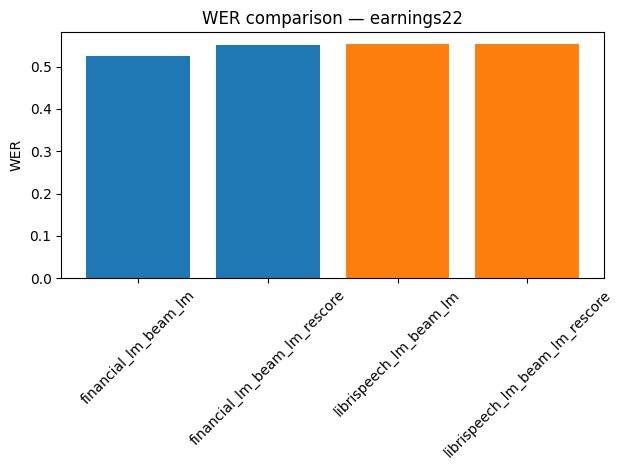

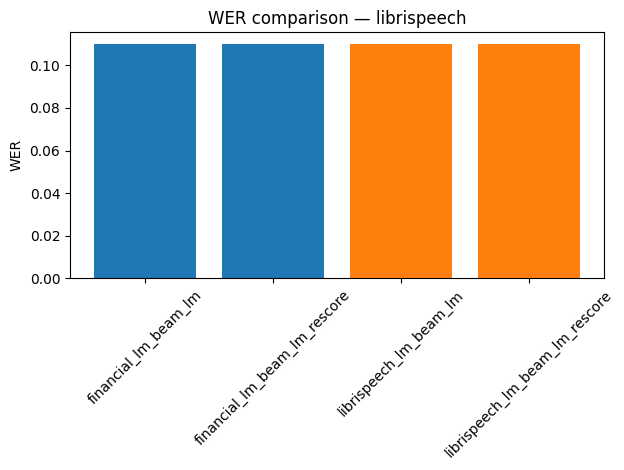

In [30]:
import matplotlib.pyplot as plt


for dataset in df["Dataset"].unique():
    subset = df[df["Dataset"] == dataset]

    plt.figure()
    for lm in subset["LM"].unique():
        lm_data = subset[subset["LM"] == lm]
        plt.bar(
            [f"{lm}_{m}" for m in lm_data["Method"]],
            lm_data["WER"]
        )

    plt.title(f"WER comparison — {dataset}")
    plt.xticks(rotation=45)
    plt.ylabel("WER")
    plt.tight_layout()
    plt.show()